# Testing the 21cmFast Output Volume

## Initialisation

In [21]:
# Import python modules
import os
import sys
import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u, constants as c
from astropy.cosmology import FlatLambdaCDM as fmodel, z_at_value as getz
import h5py
import py21cmfast as p21c
import json

# Import local oskareor models
sys.path.append("..")
from oskareor.skalow_calc import SKAMath as omath, EoRCosmology as Cosmo, FileManager as ofmg

cmap_main = "managua"

In [22]:
# Import the h5 File Data
path = ofmg.expand_path("~/oskareor.data/simulations/project1/fiducial_lightcone_simulation.h5")
file = h5py.File(path)
data = np.array(file['lightcones']['brightness_temp'])
dist = np.array(file['lightcone_distances'])
inpd = p21c.io.h5.read_inputs(file)

print(list(file))

['InputParameters', 'global_quantities', 'lightcone_distances', 'lightcones', 'photon_nonconservation_data']


In [23]:
print(json.dumps(inpd.asdict(), indent=4, sort_keys=True, default=str))

{
    "astro_options": {
        "CELL_RECOMB": false,
        "FIX_VCB_AVG": false,
        "HALO_SCALING_RELATIONS_MEDIAN": false,
        "HEAT_FILTER": "spherical-tophat",
        "HII_FILTER": "sharp-k",
        "INTEGRATION_METHOD_ATOMIC": "GAUSS-LEGENDRE",
        "INTEGRATION_METHOD_MINI": "GAUSS-LEGENDRE",
        "IONISE_ENTIRE_SPHERE": false,
        "LYA_MULTIPLE_SCATTERING": false,
        "M_MIN_in_Mass": true,
        "PHOTON_CONS_TYPE": "no-photoncons",
        "RECOMB_MODEL": "inhomogeneous",
        "USE_ADIABATIC_FLUCTUATIONS": true,
        "USE_CMB_HEATING": true,
        "USE_EXP_FILTER": false,
        "USE_LYA_HEATING": true,
        "USE_MINI_HALOS": false,
        "USE_TS_FLUCT": true,
        "USE_UPPER_STELLAR_TURNOVER": false,
        "USE_X_RAY_HEATING": true
    },
    "astro_params": {
        "ALPHA_ESC": -0.46,
        "ALPHA_STAR": 0.51,
        "ALPHA_STAR_MINI": 0.51,
        "ALPHA_UVB": 5.0,
        "A_LW": 2.0,
        "A_VCB": 1.0,
        "BETA

In [24]:
print(data.shape)

(512, 512, 1024)


In [25]:
# Cosmology data
cosmo = inpd.cosmo_params.cosmo
btzs = getz(cosmo.comoving_distance, dist * u.Mpc).to_value()
print(btzs)

[ 5.50000001  5.5041941   5.50839227 ... 13.41934869 13.43317339
 13.44701797]


## Global Parameters

Printing global parameters against the node redshifts.

In [26]:
print(list(file['global_quantities']))

['brightness_temp', 'cumulative_recombinations', 'density', 'ionisation_rate_G12', 'kinetic_temp_neutral', 'kinetic_temperature', 'log10_mturn_acg', 'log10_mturn_mcg', 'mean_free_path', 'neutral_fraction', 'spin_temperature', 'tau_21', 'unnormalised_nion', 'velocity_z', 'xray_ionised_fraction', 'z_reion']


In [27]:
nzs = np.array(inpd.node_redshifts)
gtbs = np.array(file['global_quantities']['brightness_temp'])
xh1s = np.array(file['global_quantities']['neutral_fraction'])

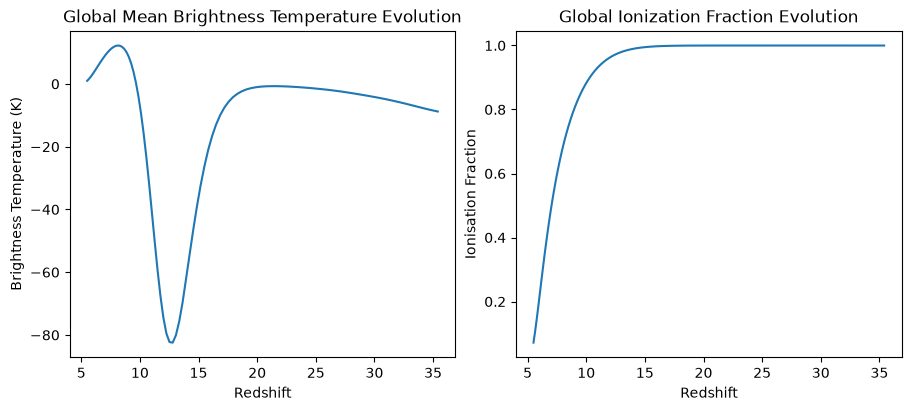

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=2, layout="constrained")
fig.set_size_inches((9, 4))

ax[0].plot(nzs, gtbs)
ax[0].set_xlabel("Redshift")
ax[0].set_ylabel("Brightness Temperature (K)")
ax[0].set_title("Global Mean Brightness Temperature Evolution")

ax[1].plot(nzs, xh1s)
ax[1].set_xlabel("Redshift")
ax[1].set_ylabel("Ionisation Fraction")
ax[1].set_title("Global Ionization Fraction Evolution")

plt.show()

Concerningly it does seem like the ionisation fraction **does not** follow an expected logistic curve but instead a flat logarithmic curve. This could also be because of the nature of the simulation and the chosen redshifts.

## Transverse Dimension Snapshots

Now we will see different snapshots of the saved lightcone volume at different redshifts.

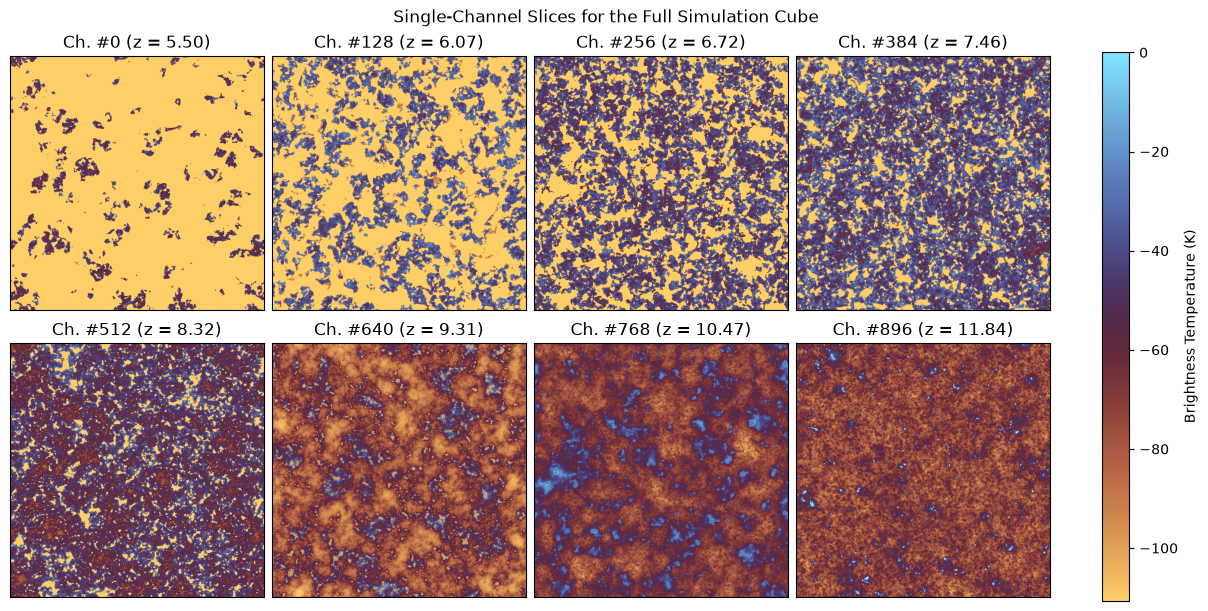

In [29]:
channels = np.arange(8) * 128

fig, ax = plt.subplots(nrows=2, ncols=4, layout="constrained", squeeze=True)
fig.set_size_inches((12,6))
ax = ax.flatten()

fig.suptitle("Single-Channel Slices for the Full Simulation Cube")

for i, chn in enumerate(channels):
    im = ax[i].imshow(data[:,:,chn], cmap=cmap_main)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(f"Ch. #{chn} (z = {btzs[chn]:3.2f})")
    
fig.colorbar(im, ax=ax.ravel().tolist(), label="Brightness Temperature (K)")

plt.show()

## Plotting Lightcones

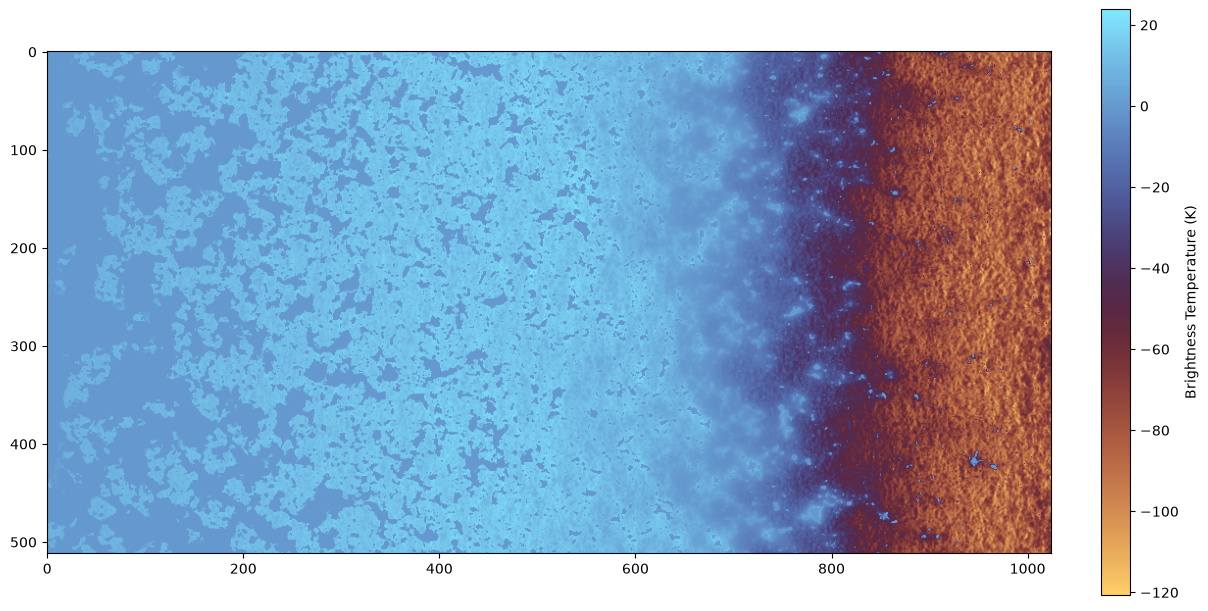

In [31]:
fig, ax = plt.subplots(layout="constrained")
fig.set_size_inches((12,6))

im = ax.imshow(data[:,256,:], cmap=cmap_main)
fig.colorbar(im, ax=ax, label="Brightness Temperature (K)")

plt.show()